In [1]:
from datetime import datetime
import pandas as pd
import networkx as nx
from collections import Counter
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
def get_critical_nodes(G, top_n=10):
    degree = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    eigen = nx.eigenvector_centrality(G, max_iter=1000)

    # Sort and return top nodes
    def top_from_dict(d):
        return sorted(d.items(), key=lambda x: x[1], reverse=True)[:top_n]

    return {
        "Degree": top_from_dict(degree),
        "Betweenness": top_from_dict(betweenness),
        "Closeness": top_from_dict(closeness),
        "Eigenvector": top_from_dict(eigen),
    }


In [3]:
def simulate_resilience(G, removal_strategy='random', fraction=0.2, centrality_type='betweenness'):
    """
    Simulates resilience testing by removing a fraction of nodes from the graph
    and measuring the impact on the largest connected component.
    """
    G = G.copy()
    num_remove = int(fraction * G.number_of_nodes())
    
    if removal_strategy == 'random':
        nodes_to_remove = np.random.choice(list(G.nodes), size=num_remove, replace=False)
    elif removal_strategy == 'centrality':
        centrality = None
        if centrality_type == 'degree':
            centrality = nx.degree_centrality(G)
        elif centrality_type == 'betweenness':
            centrality = nx.betweenness_centrality(G)
        elif centrality_type == 'closeness':
            centrality = nx.closeness_centrality(G)
        elif centrality_type == 'eigenvector':
            centrality = nx.eigenvector_centrality(G, max_iter=1000)
        else:
            raise ValueError("Unsupported centrality type")

        nodes_to_remove = sorted(centrality, key=centrality.get, reverse=True)[:num_remove]
    else:
        raise ValueError("Invalid removal_strategy")

    G.remove_nodes_from(nodes_to_remove)

    # Measure size of largest component
    if len(G) == 0 or len(list(nx.connected_components(G))) == 0:
        largest_cc_size = 0
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        largest_cc_size = len(largest_cc)

    return largest_cc_size / G.number_of_nodes()


In [4]:
def plot_resilience_curve(G, removal_strategy, centrality_type=None):
    fractions = np.linspace(0.0, 0.5, 11)
    sizes = []
    
    for frac in fractions:
        size = simulate_resilience(G, removal_strategy, frac, centrality_type)
        sizes.append(size)

    plt.plot(fractions, sizes, marker='o')
    plt.xlabel('Fraction of nodes removed')
    plt.ylabel('Fraction of largest connected component remaining')
    plt.title(f'Resilience curve - Strategy: {removal_strategy} ({centrality_type})')
    plt.grid(True)
    plt.show()




In [ ]:
# Load your graph (or use one you just created)
G = nx.read_gml('../Networks/t3_r007p_f007p.gml')

# Identify top critical nodes
critical_nodes = get_critical_nodes(G)
for key in critical_nodes:
    print(f"Top {key} nodes:")
    for node, score in critical_nodes[key]:
        print(f"  {node}: {score:.4f}")

# Simulate random and targeted failures
random_resilience = simulate_resilience(G, removal_strategy='random', fraction=0.1)
targeted_resilience_deg = simulate_resilience(G, removal_strategy='centrality', fraction=0.1, centrality_type='degree')
targeted_resilience_bet = simulate_resilience(G, removal_strategy='centrality', fraction=0.1, centrality_type='betweenness')
targeted_resilience_clos = simulate_resilience(G, removal_strategy='centrality', fraction=0.1, centrality_type='closeness')
targeted_resilience_eig = simulate_resilience(G, removal_strategy='centrality', fraction=0.1, centrality_type='eigenvector')

print(f"\nResilience after 10% random node removal: {random_resilience:.2f}")
print(f"Resilience after 10% targeted removal (degree): {targeted_resilience_deg:.2f}")
print(f"Resilience after 10% targeted removal (betweenness): {targeted_resilience_bet:.2f}")
print(f"Resilience after 10% targeted removal (closeness): {targeted_resilience_clos:.2f}")
print(f"Resilience after 10% targeted removal (eigenvector): {targeted_resilience_eig:.2f}")


Top Degree nodes:
  92699: 0.0060
  52770: 0.0060
  34945: 0.0055
  81611: 0.0050
  82942: 0.0050
  85769: 0.0050
  82213: 0.0050
  68999: 0.0050
  7804: 0.0050
  96896: 0.0045
Top Betweenness nodes:
  41852: 0.0116
  2276: 0.0116
  56104: 0.0116
  84184: 0.0116
  7111: 0.0105
  98242: 0.0104
  64085: 0.0103
  73483: 0.0101
  13437: 0.0101
  75562: 0.0095
Top Closeness nodes:
  70117: 0.0143
  66480: 0.0140
  86480: 0.0139
  87802: 0.0138
  40564: 0.0137
  48274: 0.0136
  13114: 0.0134
  65071: 0.0134
  24955: 0.0133
  64484: 0.0133
Top Eigenvector nodes:
  52770: 0.3510
  34945: 0.3330
  82942: 0.3311
  82213: 0.3249
  39793: 0.3142
  17197: 0.3094
  96896: 0.2911
  20069: 0.2842
  60029: 0.2229
  78205: 0.1679

Resilience after 10% random node removal: 0.12
Resilience after 10% targeted removal (degree): 0.06
Resilience after 10% targeted removal (betweenness): 0.03
Resilience after 10% targeted removal (closeness): 0.05
Resilience after 10% targeted removal (eigenvector): 0.11


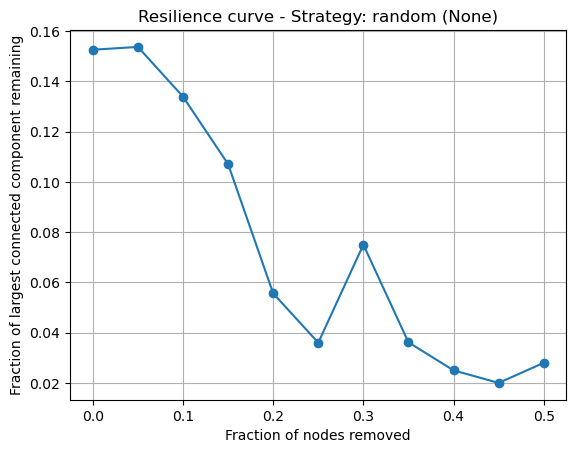

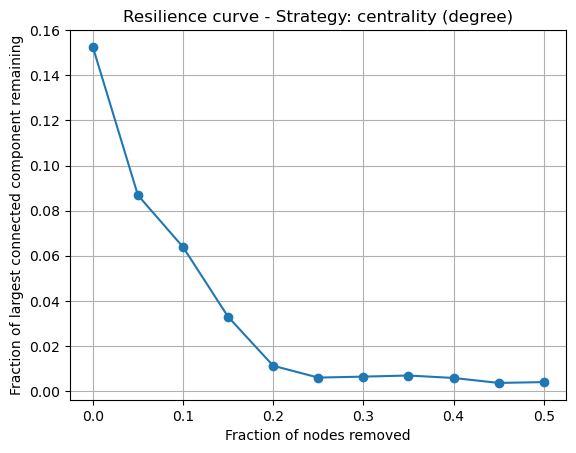

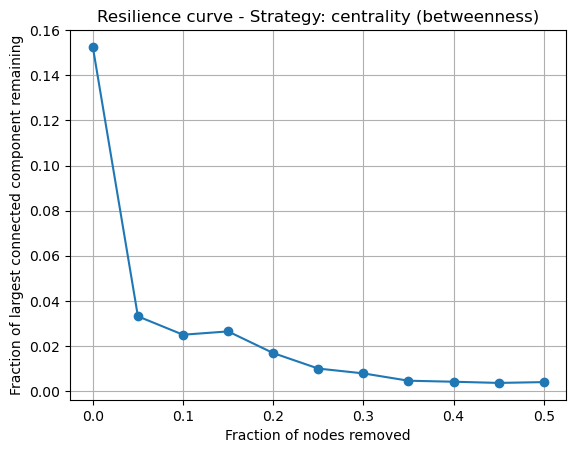

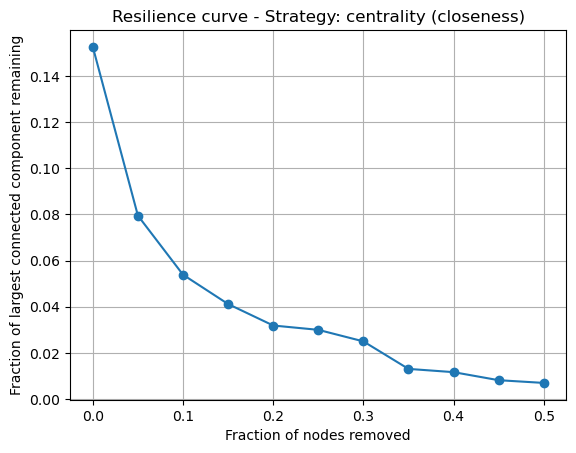

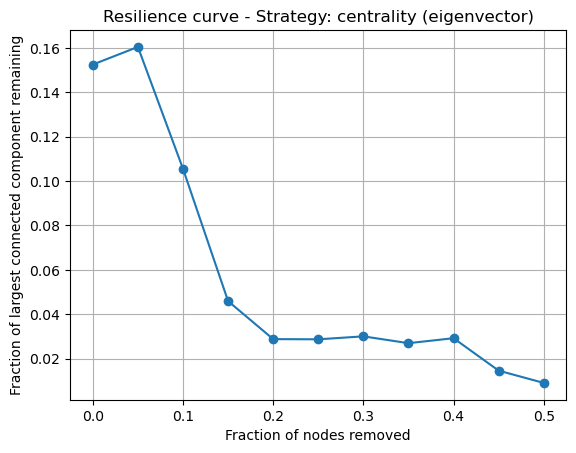

In [6]:
# Example: Plot for random and betweenness-based removal
plot_resilience_curve(G, 'random')
plot_resilience_curve(G, 'centrality', 'degree')
plot_resilience_curve(G, 'centrality', 'betweenness')
plot_resilience_curve(G, 'centrality', 'closeness')
plot_resilience_curve(G, 'centrality', 'eigenvector')